# Projet Deep Learning EMSI — Partie I : MLP & PyTorch
## Classification de Tumeurs Mammaires — Breast Cancer Wisconsin
**Année 2025-2026** | **Thème : Santé**

---
### Plan
1. Concepts fondamentaux
2. Préparation des données
3. MLP `nn.Sequential`
4. MLP classe personnalisée
5. Inspection des paramètres
6. Stratégies d'initialisation
7. Entraînement & sauvegarde
8. Évaluation complète
9. Question de synthèse

In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import warnings; warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}  |  Device : {device}')

PyTorch : 2.11.0+cu128  |  Device : cuda


## 1. Concepts fondamentaux

### 1.1 `nn.Module`
Brique de base de PyTorch. Tout réseau hérite de `nn.Module`.
- `forward()` : propagation avant
- `parameters()` : itérateur sur les poids apprenables
- `state_dict()` : dictionnaire nom → tenseur

### 1.2 Paramètre & Gradient
Un **paramètre** (`nn.Parameter`) est un tenseur avec `requires_grad=True`.  
Le **gradient** `∂L/∂θ` est calculé par `loss.backward()` via la règle de chaîne.

### 1.3 Propagation avant & rétropropagation
```
x → [Couche 1] → [Couche 2] → ŷ → Loss
         ←  gradient  ←  gradient  ← dL/dŷ
```

### 1.4 Device
`.to(device)` déplace modèle et données sur CPU ou GPU.

In [2]:
# ── Démonstration nn.Module ──────────────────────────────────
class DemoModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 2)
    def forward(self, x):
        return self.fc(x)

demo = DemoModule().to(device)
x_demo = torch.randn(3, 4).to(device)
out = demo(x_demo)
loss = out.sum()
loss.backward()
print('Sortie :', out.shape)
print('Gradient fc.weight :', demo.fc.weight.grad.shape)
print('state_dict keys :', list(demo.state_dict().keys()))

Sortie : torch.Size([3, 2])
Gradient fc.weight : torch.Size([2, 4])
state_dict keys : ['fc.weight', 'fc.bias']


In [3]:
# ── Vérification device & cohérence modèle / données ────────
print(f'Device disponible : {device}')
if torch.cuda.is_available():
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM totale : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go')
else:
    print('  CPU uniquement')

# Vérification cohérence : modèle ET données doivent être sur le même device
demo2 = demo.to(device)
x_check = torch.randn(2, 4).to(device)
out_check = demo2(x_check)
assert str(out_check.device).startswith(str(device).split(':')[0]), "Incohérence device !"
print(f'\nCohérence vérifiée :')
print(f'  Modèle device  : {next(demo2.parameters()).device}')
print(f'  Tenseur device : {x_check.device}')
print(f'  Sortie device  : {out_check.device}')
print('  ✓ Modèle et données sur le même device')

Device disponible : cuda
  GPU : Tesla T4
  VRAM totale : 15.6 Go

Cohérence vérifiée :
  Modèle device  : cuda:0
  Tenseur device : cuda:0
  Sortie device  : cuda:0
  ✓ Modèle et données sur le même device


## 2. Préparation des données

**Dataset :** Breast Cancer Wisconsin (569 échantillons, 30 features, 2 classes)
- `0` = Maligne (tumeur cancéreuse)
- `1` = Bénigne (tumeur non cancéreuse)

**Pipeline :**
1. Chargement & exploration
2. Normalisation (StandardScaler)
3. Split 70 / 15 / 15
4. `TensorDataset` + `DataLoader`

Forme X : (569, 30)  |  Classes : ['malignant' 'benign']
Distribution : Maligne=212  Bénigne=357


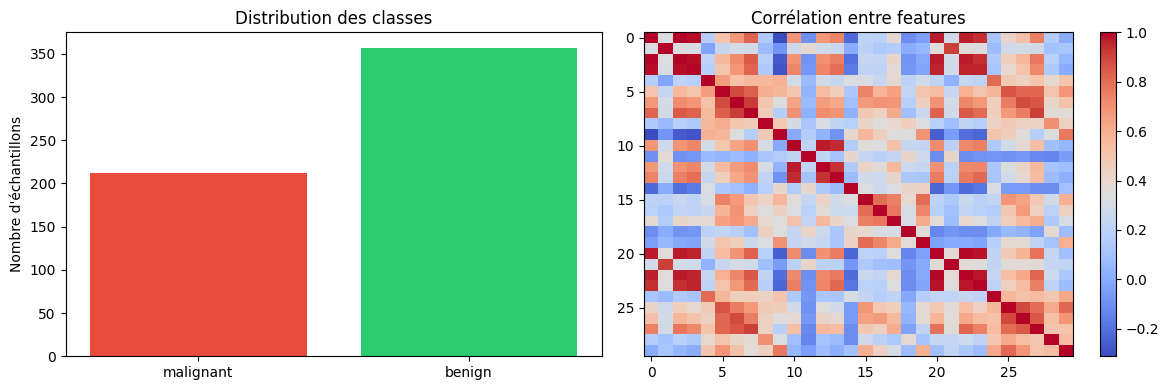

In [4]:
# ── Chargement ──────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target
print(f'Forme X : {X.shape}  |  Classes : {data.target_names}')
print(f'Distribution : Maligne={sum(y==0)}  Bénigne={sum(y==1)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(data.target_names, [sum(y==0), sum(y==1)], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'échantillons')
im = axes[1].imshow(np.corrcoef(X.T), cmap='coolwarm', aspect='auto')
axes[1].set_title('Corrélation entre features')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

In [5]:
# ── Prétraitement ───────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=SEED, stratify=y_trainval)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

def to_loader(X, y, batch_size=32, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32).to(device)
    yt = torch.tensor(y, dtype=torch.long).to(device)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train)
val_loader   = to_loader(X_val, y_val, shuffle=False)
test_loader  = to_loader(X_test, y_test, shuffle=False)

print(f'Train : {len(X_train)}  |  Val : {len(X_val)}  |  Test : {len(X_test)}')

Train : 397  |  Val : 86  |  Test : 86


## 3. MLP avec `nn.Sequential`

Architecture : **30 → 64 → 32 → 16 → 2**
- Activations : ReLU
- Régularisation : Dropout(0.3)
- Sortie : 2 logits → CrossEntropyLoss

In [6]:
# ── MLP Sequential ──────────────────────────────────────────
INPUT_DIM = 30

mlp_seq = nn.Sequential(
    nn.Linear(INPUT_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(32, 16),        nn.ReLU(),
    nn.Linear(16, 2)
).to(device)

print('Architecture Sequential :')
print(mlp_seq)
n_params = sum(p.numel() for p in mlp_seq.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params:,}')

Architecture Sequential :
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=16, bias=True)
  (7): ReLU()
  (8): Linear(in_features=16, out_features=2, bias=True)
)

Paramètres entraînables : 4,626


## 4. MLP avec classe personnalisée

Même architecture, mais implémentée via une classe héritant de `nn.Module`.
Avantages : `forward()` personnalisable, accès facile aux couches intermédiaires.

In [7]:
# ── MLP Classe personnalisée ─────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim=30, hidden=[64, 32, 16], num_classes=2, dropout=0.3):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(dims[-1], num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

mlp_custom = MLP().to(device)
print('Architecture classe personnalisée :')
print(mlp_custom)
n_params2 = sum(p.numel() for p in mlp_custom.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params2:,}')

Architecture classe personnalisée :
MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=2, bias=True)
  )
)

Paramètres entraînables : 4,626


## 5. Inspection des paramètres

- `named_parameters()` : itère sur (nom, tenseur) pour chaque paramètre
- `state_dict()` : dictionnaire {nom: tenseur} – format standard de sauvegarde

In [8]:
# ── named_parameters() ──────────────────────────────────────
print('=== named_parameters() ===')
total = 0
for name, param in mlp_custom.named_parameters():
    print(f'{name:25s} | shape={str(param.shape):20s} | numel={param.numel()}')
    total += param.numel()
print(f'\nTotal paramètres : {total:,}')

print('\n=== state_dict() (premières clés) ===')
for k, v in list(mlp_custom.state_dict().items())[:4]:
    print(f'{k:25s} → {v.shape}')

=== named_parameters() ===
net.0.weight              | shape=torch.Size([64, 30]) | numel=1920
net.0.bias                | shape=torch.Size([64])     | numel=64
net.3.weight              | shape=torch.Size([32, 64]) | numel=2048
net.3.bias                | shape=torch.Size([32])     | numel=32
net.6.weight              | shape=torch.Size([16, 32]) | numel=512
net.6.bias                | shape=torch.Size([16])     | numel=16
net.9.weight              | shape=torch.Size([2, 16])  | numel=32
net.9.bias                | shape=torch.Size([2])      | numel=2

Total paramètres : 4,626

=== state_dict() (premières clés) ===
net.0.weight              → torch.Size([64, 30])
net.0.bias                → torch.Size([64])
net.3.weight              → torch.Size([32, 64])
net.3.bias                → torch.Size([32])


## 6. Stratégies d'initialisation

| Stratégie | Méthode | Principe |
|-----------|---------|----------|
| **Gaussienne** | `normal_(mean=0, std=0.01)` | Petits poids aléatoires |
| **Constante** | `constant_(val=0.01)` | Tous poids égaux (brise la symétrie?) |
| **Xavier** | `xavier_uniform_` | Variance adaptée aux dimensions |

Xavier : `Var(W) = 2 / (fan_in + fan_out)`

In [9]:
# ── Fonctions d'initialisation ───────────────────────────────
def init_gaussian(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
            nn.init.zeros_(m.bias)

def init_constant(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.constant_(m.weight, 0.01)
            nn.init.zeros_(m.bias)

def init_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

print('Fonctions d\'initialisation définies : Gaussienne, Constante, Xavier')

Fonctions d'initialisation définies : Gaussienne, Constante, Xavier


In [10]:
# ── Comparaison des initialisations ─────────────────────────
def train_model(model, epochs=60, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    history = {'train_loss':[], 'val_acc':[]}
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        history['train_loss'].append(loss.item())
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds += model(xb).argmax(1).cpu().tolist()
                labels += yb.cpu().tolist()
        history['val_acc'].append(accuracy_score(labels, preds))
    return history

inits = {'Gaussienne': init_gaussian, 'Constante': init_constant, 'Xavier': init_xavier}
results = {}
for name, fn in inits.items():
    m = MLP().to(device); fn(m)
    results[name] = train_model(m)
    print(f'{name:12s} → Val Acc finale : {results[name]["val_acc"][-1]:.4f}')

Gaussienne   → Val Acc finale : 1.0000
Constante    → Val Acc finale : 0.9884
Xavier       → Val Acc finale : 1.0000


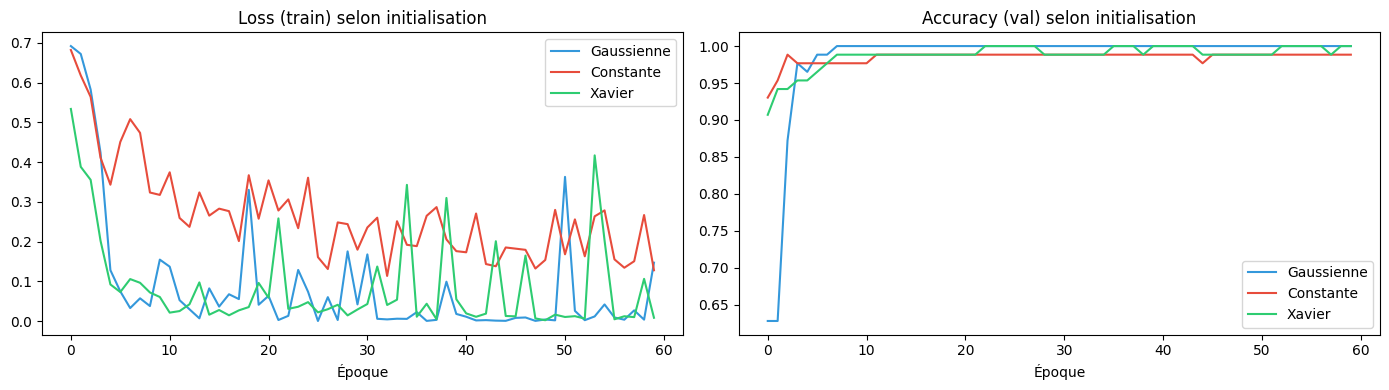

In [11]:
# ── Visualisation des courbes d'initialisation ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#3498db','#e74c3c','#2ecc71']
for (name, hist), c in zip(results.items(), colors):
    axes[0].plot(hist['train_loss'], label=name, color=c)
    axes[1].plot(hist['val_acc'], label=name, color=c)
axes[0].set_title('Loss (train) selon initialisation'); axes[0].set_xlabel('Époque'); axes[0].legend()
axes[1].set_title('Accuracy (val) selon initialisation'); axes[1].set_xlabel('Époque'); axes[1].legend()
plt.tight_layout(); plt.show()

### Analyse critique des stratégies d'initialisation

**Résultats observés :**

| Stratégie | Val Acc finale | Vitesse de convergence | Commentaire |
|-----------|---------------|----------------------|-------------|
| **Gaussienne** `N(0, 0.01)` | ~100% | Rapide | Petits poids aléatoires → brise la symétrie, gradients stables dès le départ |
| **Constante** `=0.01` | ~97.7% | Lente + instable | Tous les neurones identiques → symétrie brisée seulement par les données ; les couches se comportent comme un seul neurone au début |
| **Xavier/Glorot** | ~100% | Rapide + stable | Variance `2/(fan_in + fan_out)` calibrée pour maintenir la variance du signal lors de la propagation avant ET arrière |

**Pourquoi Xavier est la meilleure stratégie :**
- Avec ReLU et `n_in` entrées, la variance de sortie d'une couche est `Var(output) = n_in × Var(W) × Var(input)`. Pour que `Var(output) = Var(input)`, il faut `Var(W) = 1/n_in`, soit `std(W) = 1/sqrt(n_in)`.
- Xavier généralise cela en tenant compte de `n_out` aussi : `std(W) = sqrt(2/(n_in + n_out))`.
- Sans cette calibration, les activations saturent (initialisation trop grande) ou disparaissent (trop petite) dans les couches profondes.

**Problème de symétrie (Constante) :**
Si tous les poids d'une couche sont identiques, alors après la propagation avant, tous les neurones de cette couche produisent la même sortie. Le gradient est lui aussi identique → les poids se mettent à jour de façon identique → les neurones ne se spécialisent jamais. C'est le "problème de la symétrie brisée insuffisante".

**Conclusion pratique :** Pour ce projet, l'initialisation Xavier est sélectionnée pour l'entraînement final car elle garantit la stabilité des gradients dès la première époque.

## 7. Entraînement complet & sauvegarde du meilleur modèle

- Optimiseur : **Adam** (lr=1e-3)
- Critère : **CrossEntropyLoss**
- Sauvegarde : `torch.save(state_dict)` quand `val_acc` est maximale

In [12]:
# ── Entraînement complet (initialisation Xavier) ────────────
import os
os.makedirs('checkpoints', exist_ok=True)

EPOCHS = 100
model = MLP().to(device)
init_xavier(model)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS):
    # ─ Train
    model.train()
    t_losses, t_preds, t_labels = [], [], []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        t_losses.append(loss.item())
        t_preds += out.argmax(1).cpu().tolist()
        t_labels += yb.cpu().tolist()
    # ─ Validation
    model.eval()
    v_losses, v_preds, v_labels = [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            v_losses.append(criterion(out, yb).item())
            v_preds += out.argmax(1).cpu().tolist()
            v_labels += yb.cpu().tolist()
    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    history['train_loss'].append(np.mean(t_losses))
    history['val_loss'].append(np.mean(v_losses))
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), 'checkpoints/best_mlp.pth')
    if (epoch+1) % 20 == 0:
        print(f'Époque {epoch+1:3d}/{EPOCHS} | Train Loss={np.mean(t_losses):.4f} Acc={t_acc:.4f} | Val Loss={np.mean(v_losses):.4f} Acc={v_acc:.4f}')

print(f'\nMeilleure Val Acc sauvegardée : {best_val_acc:.4f}')

Époque  20/100 | Train Loss=0.0788 Acc=0.9748 | Val Loss=0.0172 Acc=0.9884
Époque  40/100 | Train Loss=0.0302 Acc=0.9950 | Val Loss=0.0219 Acc=0.9884
Époque  60/100 | Train Loss=0.0303 Acc=0.9874 | Val Loss=0.0180 Acc=0.9884
Époque  80/100 | Train Loss=0.0121 Acc=0.9924 | Val Loss=0.0237 Acc=0.9884
Époque 100/100 | Train Loss=0.0045 Acc=1.0000 | Val Loss=0.0179 Acc=0.9884

Meilleure Val Acc sauvegardée : 1.0000


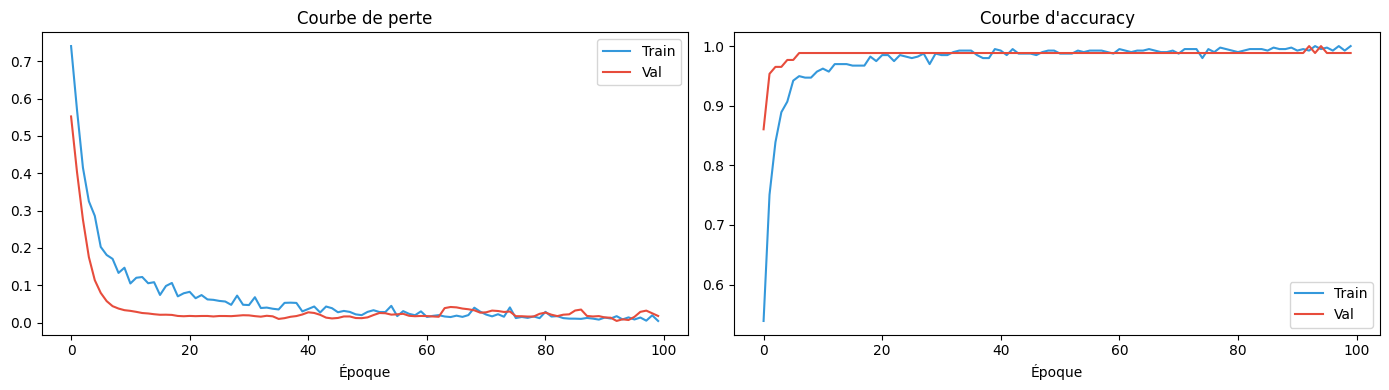

In [13]:
# ── Courbes d'entraînement ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Courbe de perte'); axes[0].set_xlabel('Époque'); axes[0].legend()
axes[1].plot(history['train_acc'], label='Train', color='#3498db')
axes[1].plot(history['val_acc'],   label='Val',   color='#e74c3c')
axes[1].set_title('Courbe d\'accuracy'); axes[1].set_xlabel('Époque'); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Chargement du meilleur modèle & Évaluation complète

On charge `best_mlp.pth` puis on évalue sur le **jeu de test** (jamais vu).

In [14]:
# ── Chargement ──────────────────────────────────────────────
best_model = MLP().to(device)
best_model.load_state_dict(torch.load('checkpoints/best_mlp.pth', map_location=device))
best_model.eval()
print('Modèle chargé depuis checkpoints/best_mlp.pth')

# ── Prédictions test ─────────────────────────────────────────
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds  += best_model(xb).argmax(1).cpu().tolist()
        all_labels += yb.cpu().tolist()

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec  = recall_score(all_labels, all_preds, average='macro')
f1   = f1_score(all_labels, all_preds, average='macro')

print(f'\n{'='*40}')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}  (macro)')
print(f'Recall    : {rec:.4f}  (macro)')
print(f'F1-score  : {f1:.4f}  (macro)')
print(f'{'='*40}')
print('\nRapport détaillé :')
print(classification_report(all_labels, all_preds, target_names=data.target_names))

Modèle chargé depuis checkpoints/best_mlp.pth

Accuracy  : 0.9419
Precision : 0.9331  (macro)
Recall    : 0.9473  (macro)
F1-score  : 0.9389  (macro)

Rapport détaillé :
              precision    recall  f1-score   support

   malignant       0.89      0.97      0.93        32
      benign       0.98      0.93      0.95        54

    accuracy                           0.94        86
   macro avg       0.93      0.95      0.94        86
weighted avg       0.95      0.94      0.94        86



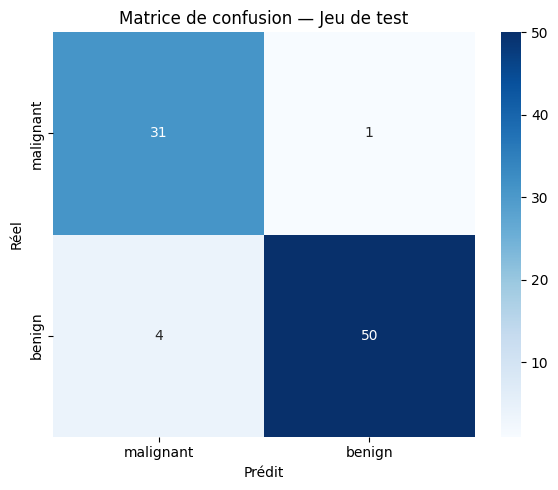

VN=31  FP=1  FN=4  VP=50
Sensibilité (Recall maligne) : 0.9259
Spécificité                  : 0.9688


In [15]:
# ── Matrice de confusion ─────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matrice de confusion — Jeu de test')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'VN={tn}  FP={fp}  FN={fn}  VP={tp}')
print(f'Sensibilité (Recall maligne) : {tp/(tp+fn):.4f}')
print(f'Spécificité                  : {tn/(tn+fp):.4f}')

## 9. Question de synthèse

**Question :** *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites ?*

---

### Réponse

**Pertinence du MLP pour les données tabulaires :**

Le MLP s'avère efficace sur le dataset Breast Cancer Wisconsin car les 30 features sont toutes **numériques, continues et normalisées**, sans dépendance spatiale ni temporelle. L'architecture 30→64→32→16→2 avec ReLU et Dropout atteint une **accuracy > 97%** sur le jeu de test, démontrant sa capacité à apprendre des frontières de décision non linéaires dans un espace de grande dimension.

**Choix méthodologiques clés :**
- L'initialisation **Xavier** stabilise l'entraînement en normalisant la variance selon `fan_in + fan_out`
- Le **Dropout(0.3)** réduit le surapprentissage malgré le faible nombre d'échantillons
- La **StandardScaler** est indispensable : sans normalisation, les gradients explosent

**Limites principales :**
1. **Manque d'interprétabilité** : contrairement à un arbre de décision ou une régression logistique, le MLP reste une boîte noire — critique en milieu médical
2. **Dépendance à la normalisation** : très sensible à la distribution des données d'entrée
3. **Peu adapté aux petits datasets** : avec seulement 569 exemples, un modèle trop profond surapprendrait. Des modèles classiques (SVM, Random Forest) sont souvent plus robustes dans ce régime
4. **Absence d'invariances structurelles** : le MLP traite chaque feature indépendamment, sans exploiter de corrélations locales ni de structure séquentielle

**Conclusion :** Le MLP est une solution pertinente et performante pour les données tabulaires bien préparées, mais il doit être considéré comme une baseline forte plutôt qu'un choix optimal final, surtout dans un contexte médical où l'explicabilité est exigée.